# A Bayesian network for obesity risk factors

A **Bayesian network** represents a joint probability distribution over many variables as a directed acyclic graph (DAG): each node is a variable, and each node depends directly only on its parents,

$$P(X_1, \dots, X_n) = \prod_i P\big(X_i \mid \text{parents}(X_i)\big).$$

The graph makes **conditional independences** explicit and the model **interpretable**: we can ask any question of the form "how does the probability of $A$ change if we know $B$ and $C$?" and see why.

On a survey about eating habits, physical condition and weight category, this notebook:

1. prepares and discretizes the data, with a critical look at how it was produced;
2. builds a network from **domain knowledge** and reads conditional independences from it (d-separation);
3. **learns a structure** from data with hill climbing and the BIC score, and compares the two graphs on held-out data;
4. estimates the conditional probability tables and answers **what-if queries**, with exact inference and with sampling.

The code uses `bayesnet.py`, a small library written for this repository (BIC scoring, hill climbing, Dirichlet parameter estimation, exact inference on the joint table, forward sampling).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

from bayesnet import DiscreteBN, bic, hill_climbing

plt.rcParams["figure.dpi"] = 100

## 1. The data

The dataset describes 2,111 people from Mexico, Peru and Colombia, aged 14 to 61, with their eating habits, physical condition and a weight category. Two facts about how it was built matter for the analysis:

- only **23%** of the records come from real survey answers; the other **77% were generated synthetically** (with the SMOTE algorithm) to balance the weight categories. Proportions in this dataset are therefore not population rates, and some relationships are amplified or created by the generator;
- the weight category was assigned from the **body mass index**, weight / height², so it is almost a deterministic function of height and weight.

We keep these limits in mind: the network will describe this dataset, not the population.

In [2]:
raw = pd.read_csv("data/obesity.csv")
print(f"{len(raw)} records, {raw.duplicated().sum()} exact duplicates removed")
raw = raw.drop_duplicates()
raw[["Age", "Gender", "Height", "Weight", "family_history_with_overweight", "NCP", "CAEC", "SMOKE", "FAF", "NObeyesdad"]].head()

2111 records, 24 exact duplicates removed


,Age,Gender,Height,Weight,family_history_with_overweight,NCP,CAEC,SMOKE,FAF,NObeyesdad
0,21.0,Female,1.62,64.0,yes,3.0,Sometimes,no,0.0,Normal_Weight
1,21.0,Female,1.52,56.0,yes,3.0,Sometimes,yes,3.0,Normal_Weight
2,23.0,Male,1.80,77.0,yes,3.0,Sometimes,no,2.0,Normal_Weight
3,27.0,Male,1.80,87.0,no,3.0,Sometimes,no,2.0,Overweight_Level_I
4,22.0,Male,1.78,89.8,no,1.0,Sometimes,no,0.0,Overweight_Level_II


We use ten variables. Bayesian networks of this kind work with discrete variables, so continuous ones are split into three groups of similar size, and ordinal survey answers are mapped to their original categories (the synthetic records contain non-integer values, which we round). The seven weight categories are merged into four.

| Variable | Meaning | Categories |
|---|---|---|
| `Age` | age (years) | 14–21, 22–26, 27+ |
| `Gender` | | Female, Male |
| `Height` | height (m) | < 1.65, 1.65–1.75, > 1.75 |
| `Weight` | weight (kg) | < 75, 75–100, > 100 |
| `FHWO` | a family member is or was overweight | no, yes |
| `NCP` | number of main meals per day | 1–2, 3, 4+ |
| `CAEC` | eating between meals | no, Sometimes, Frequently, Always |
| `Smoke` | smoker | no, yes |
| `FAF` | physical activity frequency | none, 1–2 days, 2–4 days, 4–5 days |
| `NObesity` | weight category | Underweight, Normal, Overweight, Obesity |

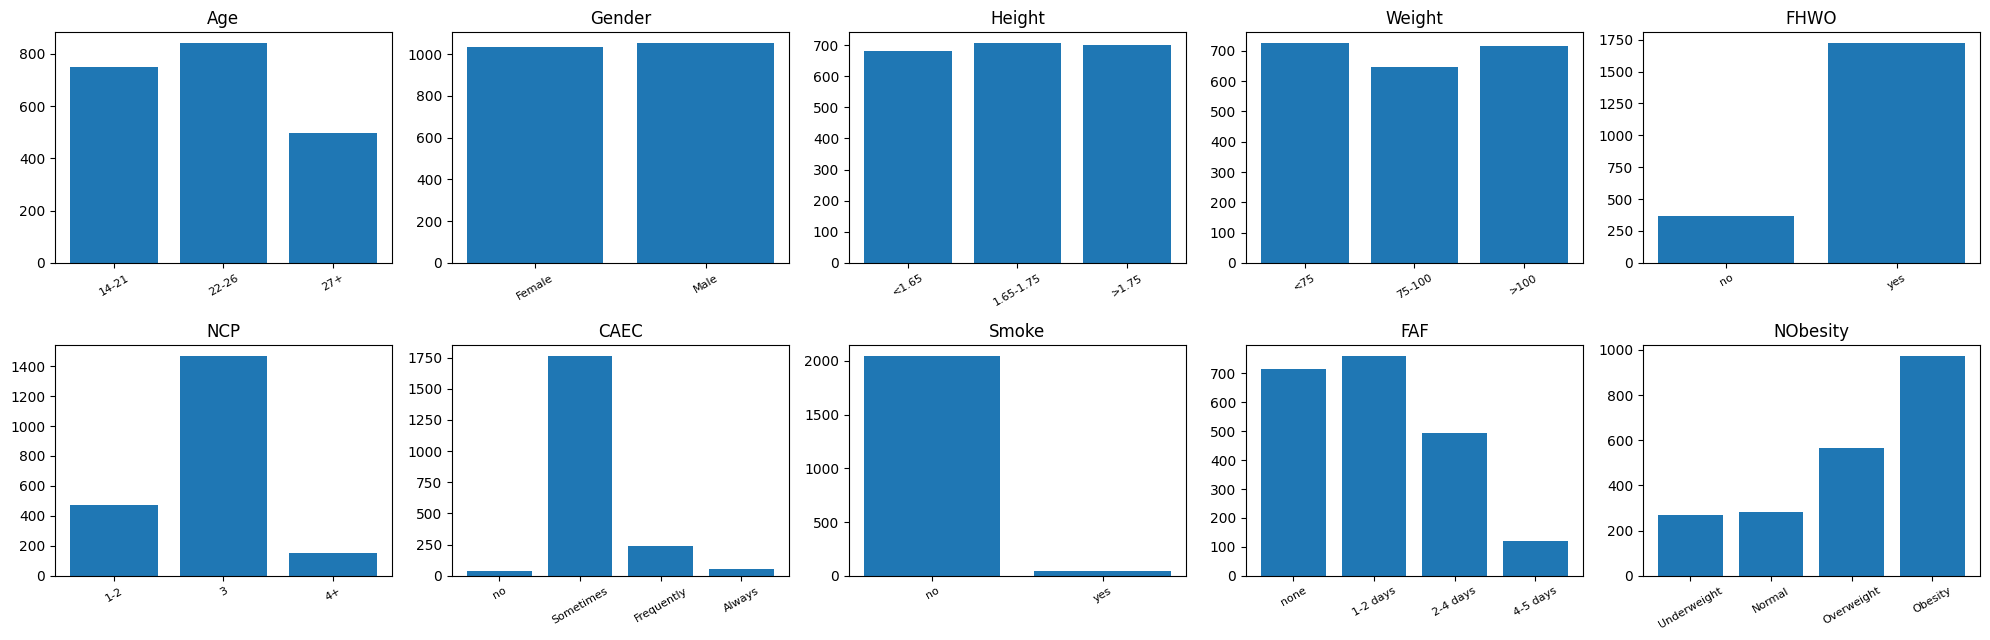

In [3]:
states = {
    "Age": ["14-21", "22-26", "27+"],
    "Gender": ["Female", "Male"],
    "Height": ["<1.65", "1.65-1.75", ">1.75"],
    "Weight": ["<75", "75-100", ">100"],
    "FHWO": ["no", "yes"],
    "NCP": ["1-2", "3", "4+"],
    "CAEC": ["no", "Sometimes", "Frequently", "Always"],
    "Smoke": ["no", "yes"],
    "FAF": ["none", "1-2 days", "2-4 days", "4-5 days"],
    "NObesity": ["Underweight", "Normal", "Overweight", "Obesity"],
}

def weight_class(label):
    for prefix, name in [("Obesity", "Obesity"), ("Overweight", "Overweight"), ("Normal", "Normal"), ("Insufficient", "Underweight")]:
        if label.startswith(prefix):
            return name

data = pd.DataFrame({
    "Age": pd.cut(raw["Age"], [0, 21, 26, 100], labels=states["Age"]),
    "Gender": raw["Gender"],
    "Height": pd.cut(raw["Height"], [0, 1.65, 1.75, 3], labels=states["Height"]),
    "Weight": pd.cut(raw["Weight"], [0, 75, 100, 300], labels=states["Weight"]),
    "FHWO": raw["family_history_with_overweight"],
    "NCP": pd.cut(raw["NCP"].round(), [0, 2, 3, 5], labels=states["NCP"]),
    "CAEC": raw["CAEC"],
    "Smoke": raw["SMOKE"],
    "FAF": raw["FAF"].round().map(dict(enumerate(states["FAF"]))),
    "NObesity": raw["NObeyesdad"].map(weight_class),
}).astype(str)

fig, axes = plt.subplots(2, 5, figsize=(20, 6.5))
for ax, col in zip(axes.flat, states):
    counts = data[col].value_counts().reindex(states[col])
    ax.bar(counts.index, counts.values, color="tab:blue")
    ax.set_title(col)
    ax.tick_params(axis="x", rotation=30, labelsize=8)
fig.tight_layout()
plt.show()

Some variables are very unbalanced: almost everyone has a family history of overweight, eats between meals "sometimes", and does not smoke (only 44 smokers). Conditional probabilities involving the rare categories will be estimated from very few records and must be read with caution.

## 2. A network from domain knowledge

Before looking at the data, we draw the dependencies we expect:

- height depends on **gender** and **age** (adolescents are still growing); smoking depends on age;
- weight depends on gender, age, eating habits (**NCP**, **CAEC**) and **family history**;
- physical activity is influenced by weight and smoking;
- the weight category depends on **weight** and **height** (it is defined from the BMI), and we also let physical activity and family history affect it directly.

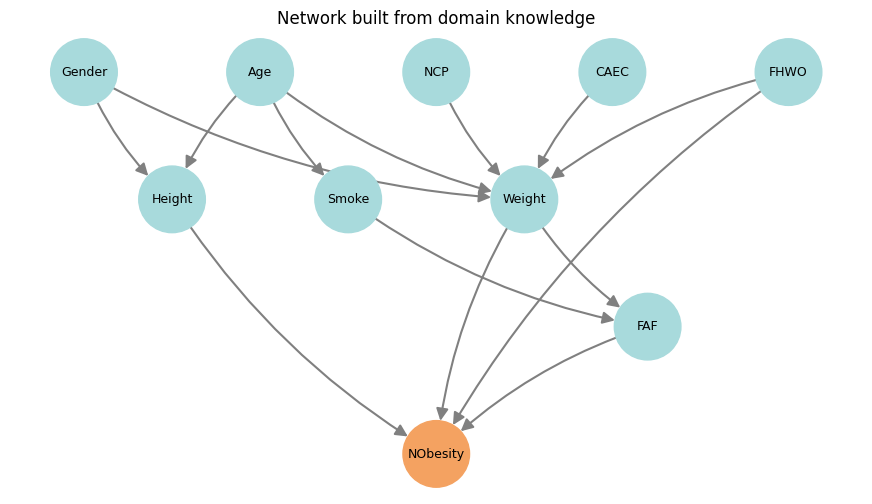

In [4]:
expert = nx.DiGraph([
    ("Gender", "Height"), ("Age", "Height"), ("Age", "Smoke"),
    ("Gender", "Weight"), ("Age", "Weight"), ("NCP", "Weight"), ("CAEC", "Weight"), ("FHWO", "Weight"),
    ("Weight", "FAF"), ("Smoke", "FAF"),
    ("Weight", "NObesity"), ("Height", "NObesity"), ("FAF", "NObesity"), ("FHWO", "NObesity"),
])
expert.add_nodes_from(states)

layout = {"Gender": (0, 3), "Age": (2, 3), "NCP": (4, 3), "CAEC": (6, 3), "FHWO": (8, 3),
          "Height": (1, 2), "Smoke": (3, 2), "Weight": (5, 2), "FAF": (6.4, 1), "NObesity": (4, 0)}

def draw(dag, ax, title, edge_colors=None, rad=0.12, pos=None):
    pos = pos or layout
    colors = ["#f4a261" if n == "NObesity" else "#a8dadc" for n in dag.nodes]
    edge_colors = edge_colors or {}
    nx.draw_networkx_nodes(dag, pos=pos, ax=ax, node_color=colors, node_size=2300)
    nx.draw_networkx_labels(dag, pos=pos, ax=ax, font_size=9)
    nx.draw_networkx_edges(dag, pos=pos, ax=ax, edge_color=[edge_colors.get(e, "grey") for e in dag.edges],
                           arrowsize=18, width=1.5, node_size=2300, connectionstyle=f"arc3,rad={rad}")
    ax.set_title(title)
    ax.axis("off")

fig, ax = plt.subplots(figsize=(11, 6))
draw(expert, ax, "Network built from domain knowledge")
plt.show()

### Reading independences: d-separation

The graph alone tells us which variables are independent given others, through **d-separation**. A path between two nodes is blocked by the conditioning set if it contains

- a chain $A \to B \to C$ or a fork $A \leftarrow B \to C$ whose middle node is observed, or
- a **collider** $A \to B \leftarrow C$ whose middle node (and all its descendants) is *not* observed.

Two variables are independent given $Z$ when every path between them is blocked.

In [5]:
checks = [
    ("Weight", "Height", []), ("Weight", "Height", ["Age", "Gender"]),
    ("CAEC", "FHWO", []), ("CAEC", "FHWO", ["Weight"]),
    ("Smoke", "Weight", []), ("Smoke", "Weight", ["Age"]),
    ("NCP", "NObesity", ["Weight"]), ("NCP", "NObesity", ["Weight", "FAF"]),
]
pd.DataFrame([{"X": x, "Y": y, "given": ", ".join(z) or "(nothing)",
               "independent?": nx.d_separated(expert, {x}, {y}, set(z))} for x, y, z in checks])

,X,Y,given,independent?
0,Weight,Height,(nothing),False
1,Weight,Height,"Age, Gender",True
2,CAEC,FHWO,(nothing),True
3,CAEC,FHWO,Weight,False
4,Smoke,Weight,(nothing),False
5,Smoke,Weight,Age,True
6,NCP,NObesity,Weight,False
7,NCP,NObesity,"Weight, FAF",False


Each line illustrates one of the three patterns:

- **Common causes (fork).** Weight and height are dependent, because both depend on age and gender. Once age and gender are known, the only paths between them are blocked and they become independent. The same holds for smoking and weight, which are linked only through age.
- **Explaining away (collider).** Snacking between meals and family history are independent: they have no common cause in the graph. But both point into `Weight`, and **observing the weight makes them dependent**. Among heavy people, someone without a family history is more likely to snack a lot, since something has to explain the weight.
- **Conditioning can open paths.** The number of meals is not independent of the weight category given the weight, even though `Weight` sits on the direct path. Observing `Weight` blocks that chain but opens the collider `NCP → Weight ← FHWO`, and family history points directly to `NObesity`. Adding physical activity to the conditioning set does not help, because this second path does not go through it.

## 3. Learning the structure from data

Instead of trusting our intuition, we can search for the DAG that best explains the data. The **BIC score** of a network is its maximized log-likelihood minus a penalty of $\tfrac{1}{2}\log N$ per free parameter, so extra edges must earn their keep. **Hill climbing** starts from the empty graph and repeatedly applies the single edge addition, removal or reversal that increases BIC the most, until no move helps. We limit each node to three parents.

To compare structures fairly, we learn on 70% of the records and evaluate on the remaining 30%.

In [6]:
rng = np.random.default_rng(0)
test_mask = rng.random(len(data)) < 0.3
train, test = data[~test_mask].reset_index(drop=True), data[test_mask].reset_index(drop=True)

learned = hill_climbing(train, states, max_parents=3, verbose=True)

add      NObesity -> Weight   (+865.4)
add      Height -> Gender   (+326.2)
add      NObesity -> FHWO   (+205.0)
add      Height -> Weight   (+203.6)
add      NObesity -> CAEC   (+167.3)
add      Age -> NObesity   (+148.9)
add      Weight -> NCP   (+57.0)
add      FAF -> Height   (+51.8)
add      Gender -> NCP   (+43.1)
add      Gender -> NObesity   (+25.8)
add      Gender -> FHWO   (+19.5)
add      Gender -> Age   (+11.4)


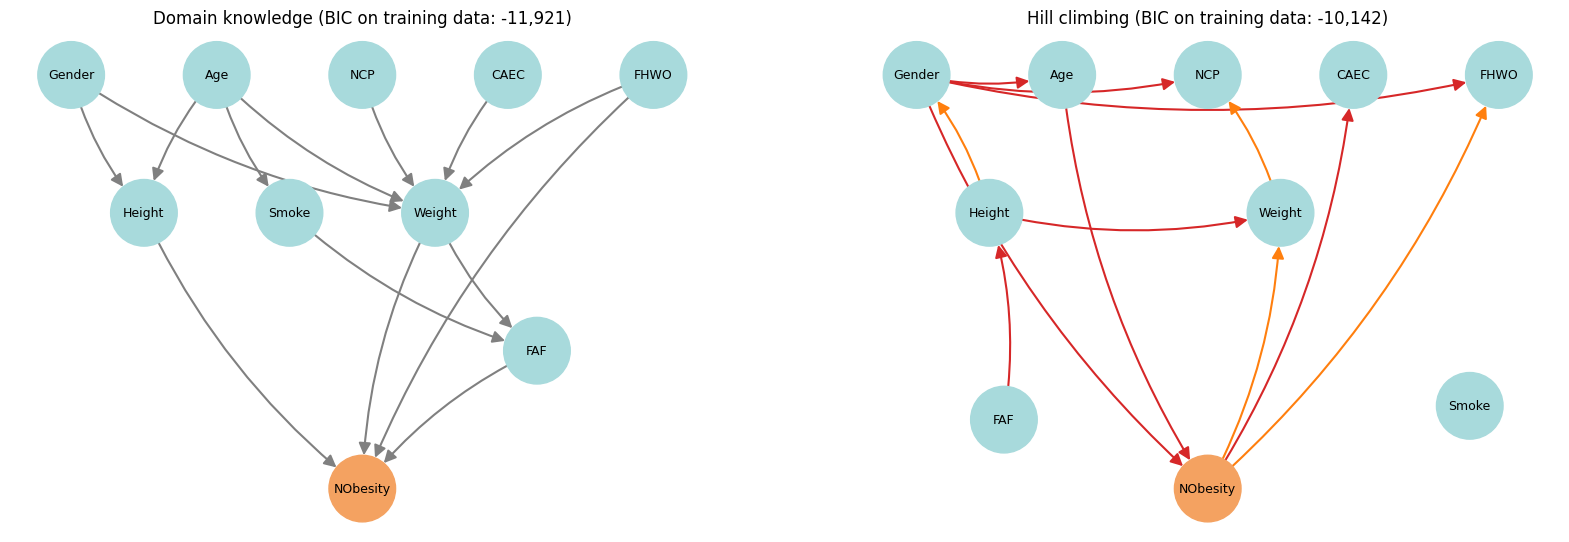

edges in both graphs: 0; reversed (orange): 4; only in the learned graph (red): 8


In [7]:
common = set(expert.edges) & set(learned.edges)
reversed_ = {(u, v) for u, v in learned.edges if (v, u) in expert.edges}
fig, axes = plt.subplots(1, 2, figsize=(20, 6.5))
draw(expert, axes[0], f"Domain knowledge (BIC on training data: {bic(train, expert, states):,.0f})")
edge_colors = {e: "grey" if e in common else "tab:orange" if e in reversed_ else "tab:red" for e in learned.edges}
draw(learned, axes[1], f"Hill climbing (BIC on training data: {bic(train, learned, states):,.0f})", edge_colors,
     pos={**layout, "Smoke": (7.6, 0.6), "FAF": (1.2, 0.5)})
plt.show()
print(f"edges in both graphs: {len(common)}; reversed (orange): {len(reversed_)}; only in the learned graph (red): {len(set(learned.edges) - common - reversed_)}")

In [8]:
def test_loglik(dag):
    bn = DiscreteBN(dag, states).fit(train)
    idx = tuple(test[c].map({s: i for i, s in enumerate(states[c])}).to_numpy() for c in bn.names)
    return np.log(bn.joint[idx]).mean(), bn

def classify_accuracy(bn):
    """Predict NObesity from all other variables with the most probable category."""
    others = [c for c in states if c != "NObesity"]
    correct = sum(bn.query("NObesity", row[others].to_dict()).idxmax() == row["NObesity"] for _, row in test.iterrows())
    return correct / len(test)

results = {}
for name, dag in [("domain knowledge", expert), ("hill climbing", learned)]:
    ll, bn = test_loglik(dag)
    results[name] = {"edges": dag.number_of_edges(), "test log-likelihood per record": ll, "NObesity accuracy (test)": classify_accuracy(bn)}
pd.DataFrame(results).T.round(3)

,edges,test log-likelihood per record,NObesity accuracy (test)
domain knowledge,14.0,-6.893,0.784
hill climbing,12.0,-6.748,0.796


Hill climbing reaches a much higher BIC than the hand-built graph, and it also fits the **held-out** records better (higher log-likelihood per record). The two graphs agree on which variables are connected more than on the arrows: none of the expert edges appears in the same direction, four appear reversed (for example `NObesity → Weight` instead of `Weight → NObesity`), and the learned graph adds eight new ones.

Two cautions apply when reading the learned graph:

- **Arrow directions are often not identifiable from data.** Graphs that encode the same independences (for example `A → B` and `B → A`) have the same score, so the search picks one arbitrarily. `NObesity → Weight` fits as well as the reverse, but it is not a causal claim.
- **The search exploits whatever the data contain.** After the link between weight and weight category, the strongest learned edges connect the weight category to family history and to snacking. Part of these dependences may come from how the synthetic records were generated, since the generator created new records inside each weight class. Smoking, with only 44 smokers, ends up disconnected from everything.

For predicting the weight category from all other variables, the two networks are almost equally accurate (about 80% on the test records). The category is defined from height and weight, but our three-level discretization of both is too coarse to recover the BMI exactly.

## 4. Parameters and what-if queries

We now fit both conditional probability tables on all records. Parameters are estimated with a **Dirichlet prior** (one pseudo-count spread uniformly over each table), which keeps rare configurations from getting probability exactly zero. We query the domain-knowledge network, whose structure is easier to interpret, and check that the learned one tells the same story.

Inference is **exact**: with ten discrete variables the full joint distribution has only about 41,000 cells, so any conditional probability is a sum over a table.

joint table: 41,472 cells, total probability 1.000000


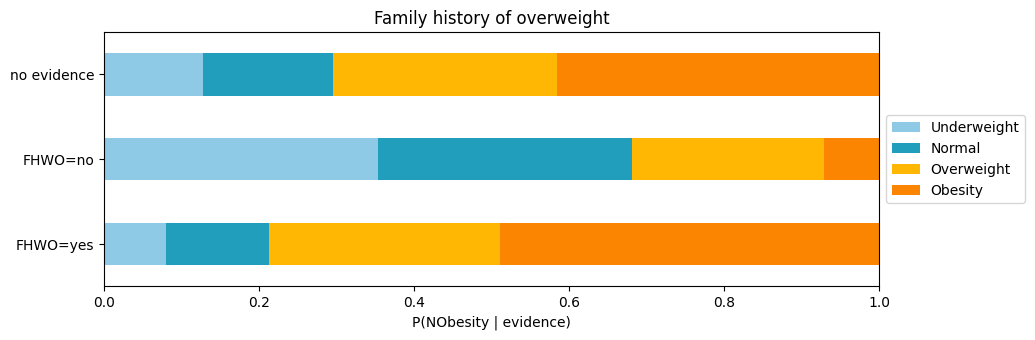

,Underweight,Normal,Overweight,Obesity
no evidence,0.127,0.168,0.290,0.416
FHWO=no,0.353,0.328,0.248,0.071
FHWO=yes,0.079,0.134,0.298,0.489


In [9]:
bn = DiscreteBN(expert, states).fit(data)
bn_learned = DiscreteBN(learned, states).fit(data)
print(f"joint table: {bn.joint.size:,} cells, total probability {bn.joint.sum():.6f}")

def compare(evidence_sets, title):
    rows = {", ".join(f"{k}={v}" for k, v in ev.items()) or "no evidence": bn.query("NObesity", ev) for ev in evidence_sets}
    table = pd.DataFrame(rows).T
    ax = table.plot.barh(stacked=True, figsize=(10, 0.6 * len(rows) + 1.5), color=["#8ecae6", "#219ebc", "#ffb703", "#fb8500"])
    ax.set(title=title, xlabel="P(NObesity | evidence)", xlim=(0, 1))
    ax.legend(loc="center left", bbox_to_anchor=(1, 0.5))
    ax.invert_yaxis()
    plt.show()
    return table.round(3)

compare([{}, {"FHWO": "no"}, {"FHWO": "yes"}], "Family history of overweight")

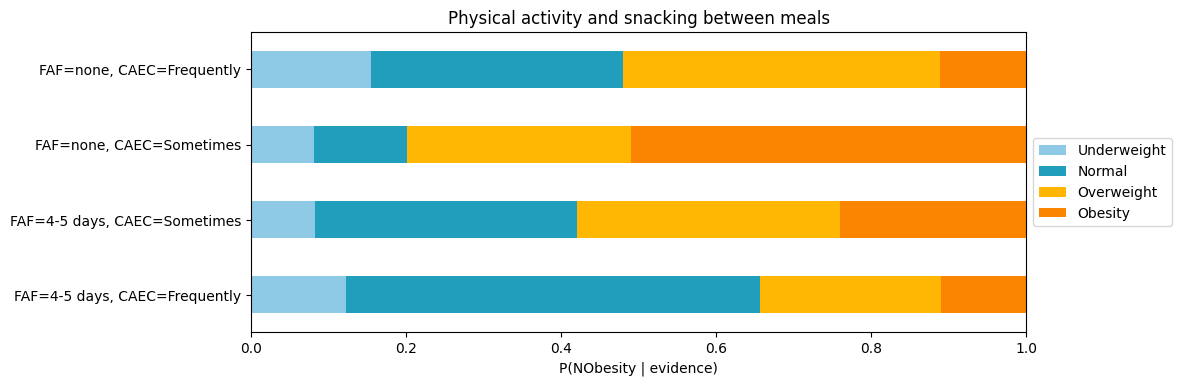

,Underweight,Normal,Overweight,Obesity
"FAF=none, CAEC=Frequently",0.155,0.325,0.409,0.111
"FAF=none, CAEC=Sometimes",0.082,0.120,0.289,0.510
"FAF=4-5 days, CAEC=Sometimes",0.083,0.337,0.340,0.240
"FAF=4-5 days, CAEC=Frequently",0.122,0.535,0.233,0.110


In [10]:
compare([{"FAF": "none", "CAEC": "Frequently"}, {"FAF": "none", "CAEC": "Sometimes"},
         {"FAF": "4-5 days", "CAEC": "Sometimes"}, {"FAF": "4-5 days", "CAEC": "Frequently"}],
        "Physical activity and snacking between meals")

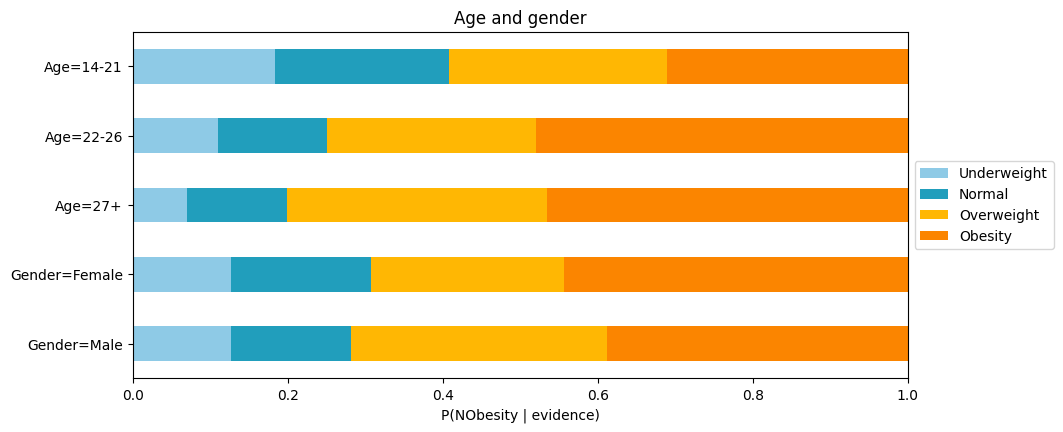

,Underweight,Normal,Overweight,Obesity
Age=14-21,0.183,0.225,0.281,0.311
Age=22-26,0.111,0.140,0.270,0.480
Age=27+,0.070,0.129,0.336,0.465
Gender=Female,0.127,0.181,0.249,0.444
Gender=Male,0.127,0.155,0.330,0.388


In [11]:
compare([{"Age": "14-21"}, {"Age": "22-26"}, {"Age": "27+"}, {"Gender": "Female"}, {"Gender": "Male"}], "Age and gender")

In [12]:
learned_check = pd.DataFrame({
    "domain knowledge": [bn.query("NObesity", {"FHWO": v})["Obesity"] for v in ("no", "yes")],
    "hill climbing": [bn_learned.query("NObesity", {"FHWO": v})["Obesity"] for v in ("no", "yes")],
}, index=["P(Obesity | FHWO = no)", "P(Obesity | FHWO = yes)"])
learned_check.round(3)

,domain knowledge,hill climbing
P(Obesity | FHWO = no),0.071,0.022
P(Obesity | FHWO = yes),0.489,0.560


Some patterns are expected, others are warnings about the data:

- **Family history** has the strongest effect: the probability of obesity is about 49% with a family history and 7% without. In the learned network the gap is even wider (56% vs 2%). This is the clearest risk factor in the dataset.
- **Age**: the youngest group has a lower probability of obesity (31%) than people over 21 (about 47%).
- **Physical activity** matters: among people who snack "sometimes", the probability of obesity drops from 51% with no activity to 24% with activity 4–5 days a week.
- **Snacking**, however, goes the "wrong" way: people who snack *frequently* have a much **lower** probability of obesity than those who snack sometimes. This is not a health finding; it reflects how the categories are distributed in this dataset, where half of the frequent snackers are in the underweight records and another third in the normal-weight ones. Bayesian networks reproduce the associations in the data faithfully, including spurious ones, and cannot tell them apart from causal effects.

### Exact inference vs sampling

For larger networks the joint table is far too big, and inference falls back to **sampling**. The simplest method, **logic sampling**, generates records from the network in topological order and keeps only those that match the evidence. Its estimate converges to the exact answer, but slowly when the evidence is rare.

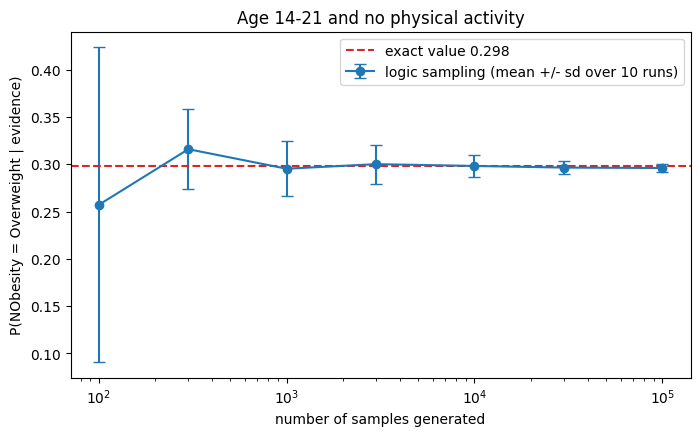

,n,mean,std,accepted samples
0,100,0.257,0.166,10.5
1,300,0.316,0.042,34.7
2,1000,0.295,0.029,117.1
3,3000,0.300,0.020,355.7
4,10000,0.298,0.012,1172.9
5,30000,0.297,0.007,3532.5
6,100000,0.296,0.004,11785.6


In [13]:
target, evidence = "Overweight", {"Age": "14-21", "FAF": "none"}
exact = bn.query("NObesity", evidence)[target]
sizes = [100, 300, 1_000, 3_000, 10_000, 30_000, 100_000]
estimates = []
for n in sizes:
    runs = [bn.logic_sampling_query("NObesity", evidence, n, seed=s) for s in range(10)]
    estimates.append({"n": n, "mean": np.mean([r[0][target] for r in runs]), "std": np.std([r[0][target] for r in runs]),
                      "accepted samples": np.mean([r[1] for r in runs])})
estimates = pd.DataFrame(estimates)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.errorbar(estimates["n"], estimates["mean"], yerr=estimates["std"], fmt="o-", capsize=4, label="logic sampling (mean +/- sd over 10 runs)")
ax.axhline(exact, color="tab:red", ls="--", label=f"exact value {exact:.3f}")
ax.set(xscale="log", xlabel="number of samples generated", ylabel=f"P(NObesity = {target} | evidence)",
       title="Age 14-21 and no physical activity")
ax.legend()
plt.show()
estimates.round(3)

Only about 12% of the generated records match the evidence (age 14–21 and no physical activity), so with 100 samples the estimate rests on about ten records and is very noisy. The error shrinks like $1/\sqrt{n_{\text{accepted}}}$: with 100,000 generated samples the estimate is within about ±0.005 of the exact value. For rarer evidence the acceptance rate drops further, which is why practical systems use smarter methods (likelihood weighting, MCMC) or exact algorithms that exploit the graph structure.

## Summary

- A Bayesian network factorizes a joint distribution along a DAG; **d-separation** reads conditional independences directly from the graph.
- A structure can be built from **domain knowledge** or **learned** with a score such as BIC. The learned graph fits better, but its edges describe statistical dependence, not causation, and many directions cannot be identified from data alone.
- With few variables, **exact inference** over the joint table answers any what-if query. Larger networks rely on sampling, whose cost explodes when the evidence is rare.
- The conclusions are only as good as the data: here a largely **synthetic** dataset and a target **defined from height and weight** limit what the network can tell us about the real world.